In [1]:
import sys
!{sys.executable} -m pip install ipywidgets jupyterlab_widgets

In [67]:
%matplotlib widget

['L0_0', 'L1_10', 'L2_5', 'L3_0', 'L4_1', 'L5_1', 'L6_0', 'L7_1', 'L8_0', 'L9_0']
{'L0_0': ['L0_0'], 'L1_10': ['L1_10', 'L1_1', 'L1_3', 'L1_2', 'L1_0', 'L1_5', 'L1_4', 'L1_6', 'L1_7', 'L1_8', 'L1_9'], 'L2_5': ['L2_5', 'L2_1', 'L2_6', 'L2_3', 'L2_4', 'L2_0', 'L2_2'], 'L3_0': ['L3_0', 'L3_1', 'L3_2'], 'L4_1': ['L4_1', 'L4_0', 'L4_2'], 'L5_1': ['L5_1', 'L5_2', 'L5_0'], 'L6_0': ['L6_0', 'L6_1', 'L6_2'], 'L7_1': ['L7_1', 'L7_0', 'L7_2'], 'L8_0': ['L8_0'], 'L9_0': ['L9_0']}
[np.str_('axon'), np.str_('axon-like')]
[np.str_('basal')]
[np.str_('apical'), np.str_('apical_shaft')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[515155.6 682080.1 955987.7]
['L0_12', 'L1_27', 'L2_2', 'L3_0', 'L4_0', 'L5_0']
{'L0_12': ['L0_12', 'L0_5', 'L0_0', 'L0_1', 'L0_8', 'L0_13', 'L0_9', 'L0_14', 'L0_3', 'L0_16', 'L0_17', 'L0_6', 'L0_18', 'L0_4', 'L0_15', 'L0_11', 'L0_2', 'L0_10', 'L0_7'], 'L1_27': ['L1_27', 'L1_22', 'L1_39', 

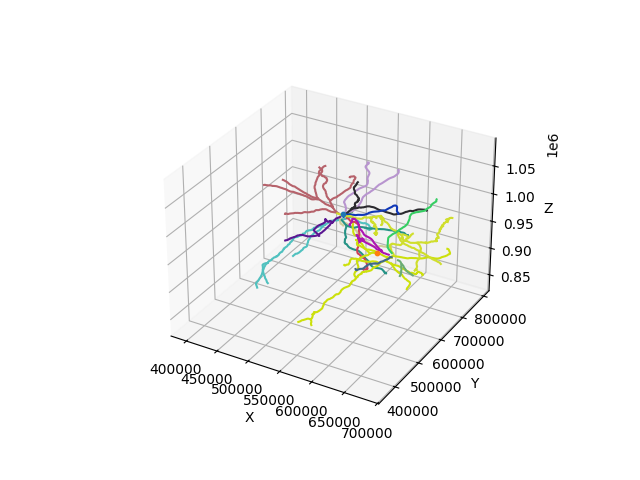

In [ ]:
import bz2
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import scipy
import random
import sys
from mpl_toolkits.mplot3d import Axes3D  # required for 3D

neuron_list = [864691135660612336, 864691136040985430] #List of neuron ids

# Unpack points

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

final_skeletonization_dict = {}

#display neurons in neuron_list with different colors for each downstream branch off of soma

for n in neuron_list:
    path= "data/graph_exports/" + str(n)+'_0_auto_proof_v7_proofread.pbz2'
    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)
        
        final_branch_dict={}
        
        first_child_list=[]
        for edge in G.edges:
            if edge[0] == "S0":
                first_child_list.append(edge[1])
        print(first_child_list)

        for node in first_child_list:
            downstream_connections = nx.descendants(G, node)
            final_branch_dict[node]=[node]
            final_branch_dict[node]+= list(downstream_connections)
            
            
        print(final_branch_dict)

        G_dict = dict(list(G.nodes(data=True)))

        skeleton_dict = {}
        
        for node in final_branch_dict:
            color = (random.random(), random.random(), random.random())
            node_list = [node] + final_branch_dict[node]
            print(G_dict[node]['labels'])
            skeleton_dict[node] = [G_dict[node]['labels'][0],np.empty((0,3))]
            for child_node in final_branch_dict[node]:
                node_data = G_dict[child_node]
                
                points = node_data['skeleton_data']
                skeleton_dict[node][1] = np.vstack((skeleton_dict[node][1], points))
                if node_data['labels'][0]=="apical":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="basal":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="axon":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)

        final_skeletonization_dict[n] = skeleton_dict
        
        center = list(G.nodes(data=True))[1][1]['endpoint_upstream']
        print(center)
        ax.scatter(center[0],center[1],center[2], s=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

['L0_18', 'L1_4', 'L2_0', 'L3_2', 'L4_2', 'L5_0']
{'L0_18': ['L0_18', 'L0_5', 'L0_8', 'L0_1', 'L0_0', 'L0_2', 'L0_12', 'L0_13', 'L0_9', 'L0_16', 'L0_3', 'L0_17', 'L0_6', 'L0_4', 'L0_15', 'L0_11', 'L0_14', 'L0_10', 'L0_7'], 'L1_4': ['L1_4', 'L1_1', 'L1_6', 'L1_5', 'L1_0', 'L1_2', 'L1_3'], 'L2_0': ['L2_0', 'L2_3', 'L2_1', 'L2_2', 'L2_4'], 'L3_2': ['L3_2', 'L3_1', 'L3_0'], 'L4_2': ['L4_2', 'L4_0', 'L4_1'], 'L5_0': ['L5_0', 'L5_1', 'L5_2']}
[np.str_('apical'), np.str_('apical_shaft')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('basal')]
[np.str_('axon'), np.str_('axon-like')]
[503777. 955642. 752564.]
['L0_0', 'L1_0']
{'L0_0': ['L0_0'], 'L1_0': ['L1_0', 'L1_1', 'L1_2']}
[np.str_('axon'), np.str_('axon-like')]
[np.str_('basal')]
[ 601731.2 1091488.   873402.6]
2277


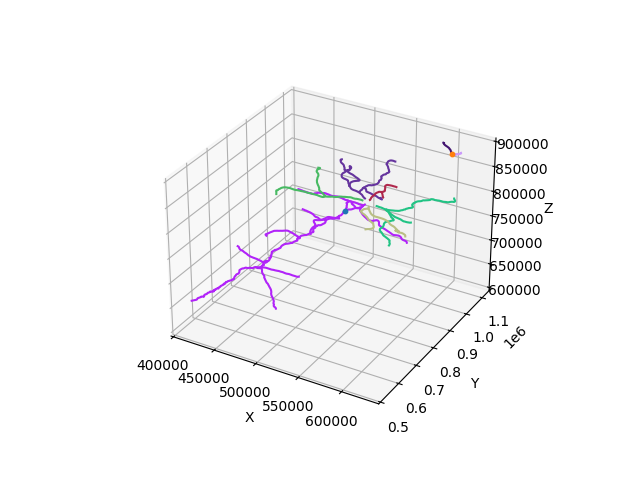

In [ ]:
#Visualize Neuron with two split ids

neuron_list = [864691135212606592] #id of neuron with two splits

# Unpack points

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


for n in neuron_list:
    path = "data/graph_exports/" + str(n)+'_0_auto_proof_v7_proofread.pbz2'
    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)
        
        final_branch_dict={}
        
        first_child_list=[]
        #print(G.edges)
        
        for edge in G.edges:
            if edge[0] == "S0":
                first_child_list.append(edge[1])
        print(first_child_list)

        for node in first_child_list:
            downstream_connections = nx.descendants(G, node)
            final_branch_dict[node]=[node]
            #print(downstream_connections)
            final_branch_dict[node]+= list(downstream_connections)
            
            
        print(final_branch_dict)

        G_dict = dict(list(G.nodes(data=True)))

        skeleton_dict = {}
        
        for node in final_branch_dict:
            color = (random.random(), random.random(), random.random())
            node_list = [node] + final_branch_dict[node]
            print(G_dict[node]['labels'])
            skeleton_dict[node] = [G_dict[node]['labels'][0],np.empty((0,3))]
            for child_node in final_branch_dict[node]:
                node_data = G_dict[child_node]
                
                points = node_data['skeleton_data']

                skeleton_dict[node][1] = np.vstack((skeleton_dict[node][1], points))
                if node_data['labels'][0]=="apical":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="basal":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="axon":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
        
        center = list(G.nodes(data=True))[1][1]['endpoint_upstream']
        print(center)
        ax.scatter(center[0],center[1],center[2], s=10)

for n in neuron_list:
    path= "data/graph_exports/" + str(n)+'_1_auto_proof_v7_proofread.pbz2'
    with bz2.open(path, 'rb') as f:
        G = pickle.load(f)
        
        final_branch_dict={}
        
        first_child_list=[]
        
        for edge in G.edges:
            if edge[0] == "S0":
                first_child_list.append(edge[1])
        print(first_child_list)

        for node in first_child_list:
            downstream_connections = nx.descendants(G, node)
            final_branch_dict[node]=[node]
            final_branch_dict[node]+= list(downstream_connections)
            
            
        print(final_branch_dict)

        G_dict = dict(list(G.nodes(data=True)))

        skeleton_dict = {}
        
        for node in final_branch_dict:
            color = (random.random(), random.random(), random.random())
            node_list = [node] + final_branch_dict[node]
            print(G_dict[node]['labels'])
            skeleton_dict[node] = [G_dict[node]['labels'][0],np.empty((0,3))]
            for child_node in final_branch_dict[node]:
                node_data = G_dict[child_node]
                
                points = node_data['skeleton_data']

                skeleton_dict[node][1] = np.vstack((skeleton_dict[node][1], points))
                if node_data['labels'][0]=="apical":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="basal":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)
                elif node_data['labels'][0]=="axon":
                    ax.plot(points[:, 0], points[:, 1], points[:, 2],color=color)

        
        center = list(G.nodes(data=True))[1][1]['endpoint_upstream']
        print(center)
        ax.scatter(center[0],center[1],center[2], s=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()